In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



# 01 Data Exploration

## Project title

**Evaluating the effect of Sentinel-2/Sentinel-3 image alignment on machine-learning prediction of melt pond fraction**

## Research question

Can Sentinel-3 OLCI multispectral reflectance be used to predict Sentinel-2-derived melt pond fraction, and does correcting Sentinel-2/Sentinel-3 spatial misalignment improve regression performance?

## Aim of this notebook

This notebook performs the first data exploration stage of the project. It loads the Week 6 Sentinel-2, Sentinel-3 OLCI, melt pond fraction, and interpolated-grid datasets, checks their structure, and produces initial visualisations.

The purpose is to understand the spatial relationship between:

- high-resolution Sentinel-2 reflectance,
- coarser Sentinel-3 OLCI reflectance,
- Sentinel-2-derived melt pond fraction,
- gridded S2/S3 data used for later image alignment.

No regression model is trained in this notebook. The goal is to confirm that the input data load correctly and to identify any spatial or coordinate issues before creating aligned and misaligned training datasets in Notebook 2.

Inputs:
- Sentinel-2 reflectance
- Sentinel-3 OLCI 21-band reflectance
- Sentinel-2-derived melt pond fraction
- Interpolated S2/S3 grids for alignment

Outputs:
- Initial data summaries
- Data exploration figures

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


PROJECT_DIR = Path("/content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression")


DATA_RAW = PROJECT_DIR / "data" / "raw"

FIG_DIR = PROJECT_DIR / "figures" / "data_exploration"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", DATA_RAW)
print("Figure directory:", FIG_DIR)

print("\nFiles in data folder:")
for f in DATA_RAW.iterdir():
    print(f.name)

Project directory: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression
Raw data directory: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/data/raw
Figure directory: /content/drive/MyDrive/GEOL0069_S2S3_MPF_Alignment_Regression/figures/data_exploration

Files in data folder:
mpf_zoomed_data.npz
s2_zoomed_data.npz
s3_zoomed_data.npz
interpolated_data.npz
training_data_subsubarea_noalign.npz


## 1. Loading the project data

The project uses pre-processed Week 6 data files:

- `s2_zoomed_data.npz`: Sentinel-2 optical reflectance and coordinates.
- `s3_zoomed_data.npz`: Sentinel-3 OLCI reflectance and coordinates.
- `mpf_zoomed_data.npz`: Sentinel-2-derived melt pond fraction.
- `interpolated_data.npz`: gridded Sentinel-2 and Sentinel-3 arrays used for image-alignment experiments.

The main machine-learning structure of the project is:

\[
X = \text{Sentinel-3 OLCI reflectance bands}
\]

\[
y = \text{Sentinel-2-derived melt pond fraction}
\]

Sentinel-2 provides the higher-resolution reference information, while Sentinel-3 OLCI provides the lower-resolution multispectral input features used for regression.

In [3]:
s2 = np.load(DATA_RAW / "s2_zoomed_data.npz")
s3 = np.load(DATA_RAW / "s3_zoomed_data.npz")
mpf = np.load(DATA_RAW / "mpf_zoomed_data.npz")
interp = np.load(DATA_RAW / "interpolated_data.npz")

print("S2 keys:", s2.files)
print("S3 keys:", s3.files)
print("MPF keys:", mpf.files)
print("Interpolated keys:", interp.files)

S2 keys: ['x', 'y', 'band_data']
S3 keys: ['x', 'y', 'reflectance']
MPF keys: ['x', 'y', 'mpf']
Interpolated keys: ['xg', 'yg', 'z_s2', 'z_s3']


In [4]:
def print_npz_summary(name, data):
    print(f"\n{name}")
    print("-" * len(name))
    for key in data.files:
        arr = data[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

print_npz_summary("Sentinel-2", s2)
print_npz_summary("Sentinel-3", s3)
print_npz_summary("MPF", mpf)
print_npz_summary("Interpolated data", interp)


Sentinel-2
----------
x: shape=(4004001,), dtype=float64
y: shape=(4004001,), dtype=float64
band_data: shape=(4004001, 3), dtype=uint16

Sentinel-3
----------
x: shape=(20238,), dtype=float64
y: shape=(20238,), dtype=float64
reflectance: shape=(20238, 21), dtype=float32

MPF
---
x: shape=(4004001,), dtype=float64
y: shape=(4004001,), dtype=float64
mpf: shape=(4004001,), dtype=float32

Interpolated data
-----------------
xg: shape=(400, 400), dtype=float64
yg: shape=(400, 400), dtype=float64
z_s2: shape=(400, 400), dtype=float64
z_s3: shape=(400, 400), dtype=float64


## 2. Dataset structure

The loaded files contain coordinate arrays and geophysical/spectral variables. Sentinel-2 has many more points than Sentinel-3 because it has finer spatial resolution. This difference in sampling density is central to the project: Sentinel-2-derived MPF must be colocated or averaged onto Sentinel-3 points before Sentinel-3 reflectance can be used as regression input.

The important variables are:

| Dataset | Variable | Meaning | Role in project |
|---|---|---|---|
| Sentinel-2 | `x`, `y` | Projected spatial coordinates | High-resolution reference grid |
| Sentinel-2 | `band_data` | Optical reflectance bands | Used for visualisation and alignment reference |
| Sentinel-3 | `x`, `y` | Projected spatial coordinates | Coarser OLCI observation locations |
| Sentinel-3 | `reflectance` | 21 OLCI reflectance bands | Machine-learning input features \(X\) |
| MPF | `mpf` | Melt pond fraction derived from Sentinel-2 | Regression target \(y\) |
| Interpolated data | `xg`, `yg`, `z_s2`, `z_s3` | Gridded S2/S3 arrays | Used to test image alignment methods |

This notebook checks whether these files are spatially consistent before they are used to build the aligned and misaligned datasets.

In [6]:
s2_x = s2["x"]
s2_y = s2["y"]
s2_bands = s2["band_data"]

s3_x = s3["x"]
s3_y = s3["y"]
s3_reflectance = s3["reflectance"]

mpf_vals = mpf["mpf"]

xg = interp["xg"]
yg = interp["yg"]
z_s2 = interp["z_s2"]
z_s3 = interp["z_s3"]

## 3. Sentinel-2 reflectance

The first visualisation shows one Sentinel-2 reflectance band over the study area. Sentinel-2 has a much denser spatial sampling than Sentinel-3, so it captures fine-scale sea-ice surface structure such as floes, darker regions, and pond-like features.

This image acts as the high-resolution optical reference for the project.

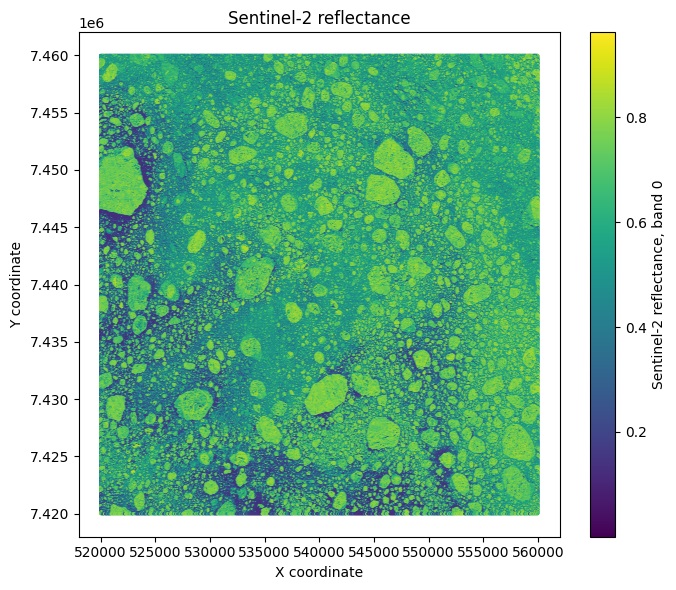

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(s2_x, s2_y, c=s2_bands[:, 0] / 10000.0, s=1, cmap="viridis")
plt.colorbar(label="Sentinel-2 reflectance, band 0")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Sentinel-2 reflectance")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_sentinel2_reflectance.png", dpi=300)
plt.show()

### Interpretation

The Sentinel-2 image shows strong fine-scale spatial structure across the sea-ice surface. Different floes and darker surface regions are clearly visible. This is important because melt ponds and other sea-ice surface types can vary over short distances.

Because Sentinel-2 resolves much finer spatial detail than Sentinel-3, the MPF target derived from Sentinel-2 must later be averaged or colocated onto the coarser Sentinel-3 grid before regression.

## 4. Sentinel-3 OLCI reflectance

The Sentinel-3 OLCI data provide 21 multispectral reflectance bands. These bands will be used as the input features for the regression models.

Compared with Sentinel-2, Sentinel-3 is spatially coarser. This means individual Sentinel-3 points represent broader surface areas, so careful colocation with Sentinel-2-derived MPF is needed.

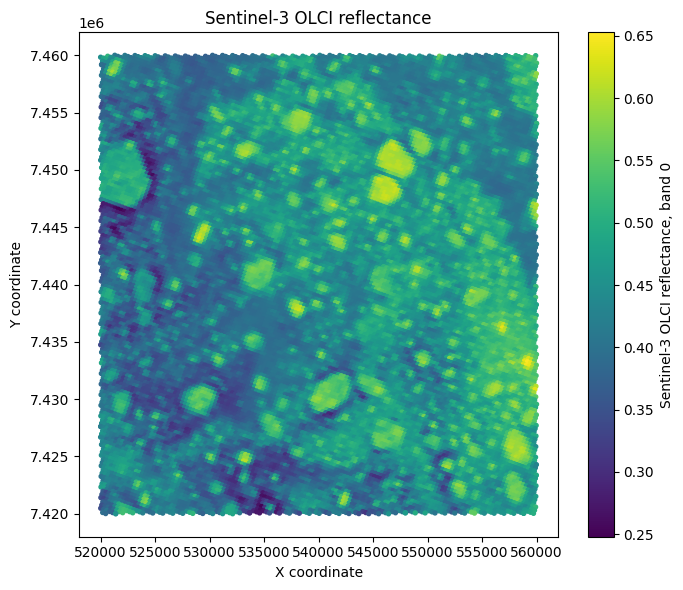

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(s3_x, s3_y, c=s3_reflectance[:, 0], s=8, cmap="viridis")
plt.colorbar(label="Sentinel-3 OLCI reflectance, band 0")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Sentinel-3 OLCI reflectance")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_sentinel3_olci_reflectance.png", dpi=300)
plt.show()

### Interpretation

The Sentinel-3 OLCI reflectance map captures similar broad spatial patterns to Sentinel-2, but at lower spatial resolution. Large-scale bright and dark regions are visible, but small-scale melt pond and floe details are smoothed compared with Sentinel-2.

This difference in resolution is one reason why the regression task is challenging: the model must learn a relationship between coarse Sentinel-3 spectral features and finer Sentinel-2-derived MPF.

## 5. Sentinel-2-derived melt pond fraction

The melt pond fraction dataset provides the target variable for the regression model. MPF represents the fraction of the surface classified as melt pond within the Sentinel-2-derived product.

This variable will later be averaged onto Sentinel-3 locations so that each Sentinel-3 OLCI reflectance vector has a corresponding MPF target.

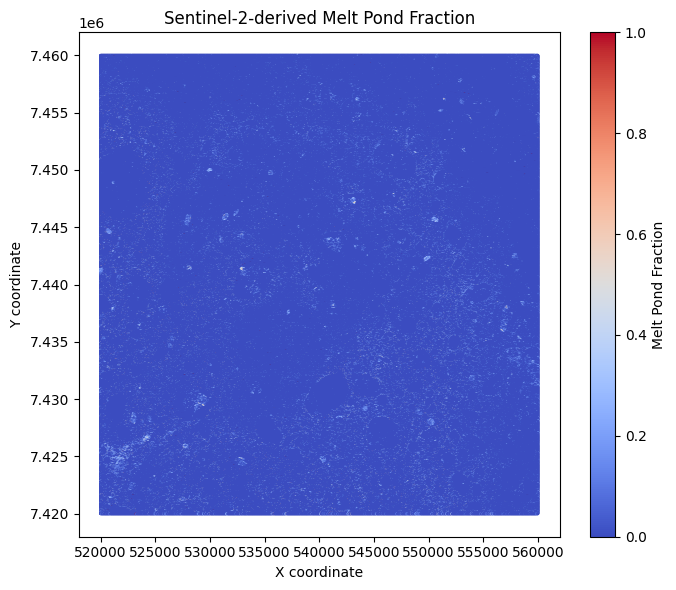

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(s2_x, s2_y, c=mpf_vals, s=1, cmap="coolwarm")
plt.colorbar(label="Melt Pond Fraction")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Sentinel-2-derived Melt Pond Fraction")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_melt_pond_fraction.png", dpi=300)
plt.show()

### Interpretation

The full 0–1 MPF colour scale shows that most of the scene has low melt pond fraction. Only small localised areas have higher MPF values.

Because most values are close to zero, the full colour scale hides much of the low-level spatial variation. A second plot with a restricted 0–0.02 colour scale is useful because it makes small but spatially meaningful MPF differences visible.

## 6. Low-range MPF visualisation

The previous MPF map used the full 0–1 range. However, the MPF values in this scene are mostly concentrated near zero. This plot restricts the colour scale to 0–0.02 to highlight low-level spatial variability in the MPF target.

This is useful because even small MPF differences may be relevant for regression performance.

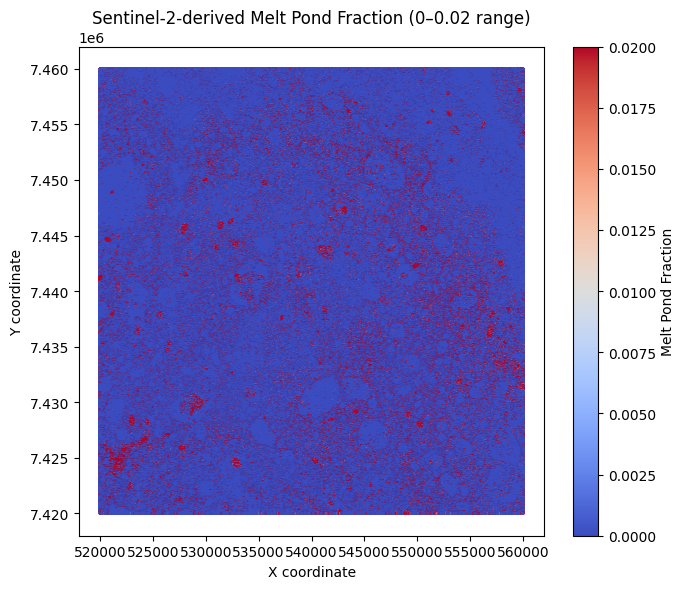

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(s2_x, s2_y, c=mpf_vals, s=1, cmap="coolwarm", vmin=0, vmax=0.02)
plt.colorbar(label="Melt Pond Fraction")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Sentinel-2-derived Melt Pond Fraction (0–0.02 range)")
plt.tight_layout()
plt.savefig(FIG_DIR / "03b_melt_pond_fraction_zoomed_colour_scale.png", dpi=300)
plt.show()

### Interpretation

The restricted colour scale reveals much more spatial structure in the MPF target. Small melt-pond-like or low-MPF variations appear across the ice surface, especially in regions that were visually compressed in the full-scale plot.

This confirms that regression performance should not be assessed only by global metrics. Spatial prediction maps and residual maps will also be needed later, because small MPF errors may still have spatial structure.

## 7. Interpolated Sentinel-2 and Sentinel-3 grids

Image alignment methods such as ECC require both images to be represented on a common grid. The `interpolated_data.npz` file contains gridded Sentinel-2 and Sentinel-3 arrays.

These gridded arrays are useful for testing image alignment because they allow the two sensors to be compared pixel-by-pixel rather than as irregular coordinate points.

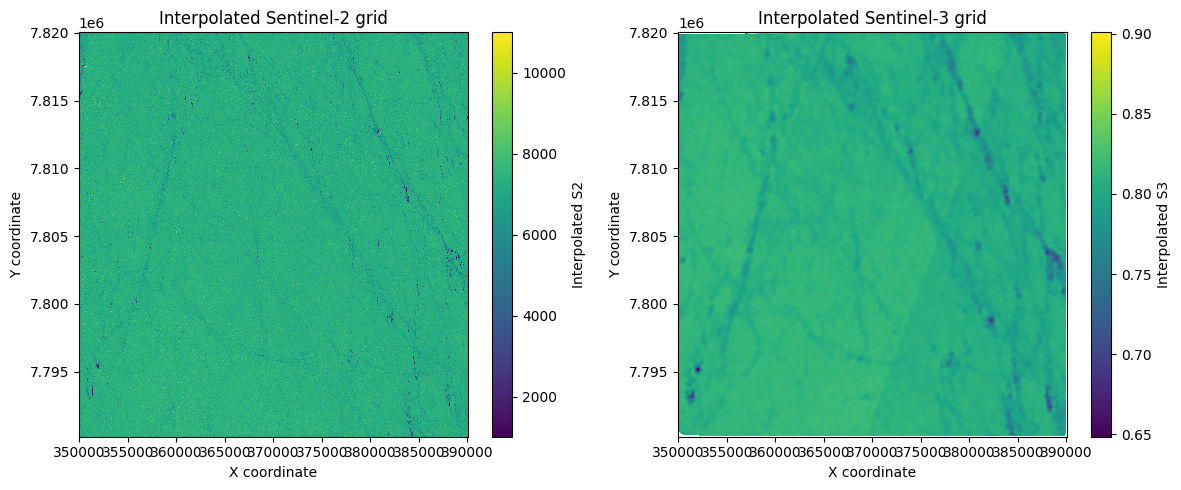

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pcolormesh(xg, yg, z_s2, shading="auto", cmap="viridis")
plt.colorbar(label="Interpolated S2")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Interpolated Sentinel-2 grid")

plt.subplot(1, 2, 2)
plt.pcolormesh(xg, yg, z_s3, shading="auto", cmap="viridis")
plt.colorbar(label="Interpolated S3")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Interpolated Sentinel-3 grid")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_interpolated_s2_s3_grids.png", dpi=300)
plt.show()

### Interpretation and coordinate check

The interpolated Sentinel-2 and Sentinel-3 grids appear visually comparable to each other, which is useful for image alignment. However, their coordinate range should be checked against the main Sentinel-2/Sentinel-3/MPF datasets.

The first three plots use coordinates around:

\[
X \approx 520000\text{–}560000,\quad Y \approx 7420000\text{–}7460000
\]

The interpolated grids appear to use a different region, approximately:

\[
X \approx 350000\text{–}390000,\quad Y \approx 7790000\text{–}7820000
\]

This suggests that `interpolated_data.npz` may not correspond to the same spatial area as the main S2/S3/MPF files used above. Therefore, in Notebook 2, the alignment grids should be regenerated directly from the current `s2_zoomed_data.npz` and `s3_zoomed_data.npz` rather than relying blindly on the provided interpolated file.

In [13]:
# Coordinate range checks

def print_xy_range(name, x, y):
    print(f"{name}")
    print(f"  X range: {np.nanmin(x):.2f} to {np.nanmax(x):.2f}")
    print(f"  Y range: {np.nanmin(y):.2f} to {np.nanmax(y):.2f}")
    print()

print_xy_range("Sentinel-2", s2_x, s2_y)
print_xy_range("Sentinel-3", s3_x, s3_y)

# MPF is usually on the Sentinel-2 grid
if "x" in mpf.files and "y" in mpf.files:
    mpf_x = mpf["x"]
    mpf_y = mpf["y"]
else:
    mpf_x = s2_x
    mpf_y = s2_y

print_xy_range("MPF", mpf_x, mpf_y)
print_xy_range("Interpolated grid", xg, yg)

Sentinel-2
  X range: 520000.00 to 560000.00
  Y range: 7420000.00 to 7460000.00

Sentinel-3
  X range: 520001.05 to 559998.38
  Y range: 7420000.75 to 7459999.16

MPF
  X range: 520000.00 to 560000.00
  Y range: 7420000.00 to 7460000.00

Interpolated grid
  X range: 350000.00 to 390000.00
  Y range: 7790230.00 to 7820000.00



In [17]:
def print_bounds(name, x, y):
    print(f"{name}")
    print(f"  x range: {np.nanmin(x):.1f} to {np.nanmax(x):.1f}")
    print(f"  y range: {np.nanmin(y):.1f} to {np.nanmax(y):.1f}")
    print()

print_bounds("Sentinel-2", s2_x, s2_y)
print_bounds("Sentinel-3", s3_x, s3_y)
print_bounds("MPF", mpf["x"], mpf["y"])
print_bounds("Interpolated grid", xg, yg)

Sentinel-2
  x range: 520000.0 to 560000.0
  y range: 7420000.0 to 7460000.0

Sentinel-3
  x range: 520001.0 to 559998.4
  y range: 7420000.8 to 7459999.2

MPF
  x range: 520000.0 to 560000.0
  y range: 7420000.0 to 7460000.0

Interpolated grid
  x range: 350000.0 to 390000.0
  y range: 7790230.0 to 7820000.0



## Coordinate range interpretation

The Sentinel-2, Sentinel-3, and MPF datasets cover the same coordinate range:

- X ≈ 520000–560000 m
- Y ≈ 7420000–7460000 m

This confirms that the main S2, S3, and MPF files are spatially compatible and can be used for colocation and regression.

The precomputed `interpolated_data.npz` file covers a different coordinate region:

- X ≈ 350000–390000 m
- Y ≈ 7790230–7820000 m

Therefore, I will not use this interpolated grid as part of the main MPF regression dataset. Instead, I will recreate any required interpolation/alignment grids directly from the S2, S3, and MPF data in the project area.

### Important note on interpolated grids

The provided `interpolated_data.npz` file appears to cover a different coordinate region from the main `s2_zoomed_data.npz`, `s3_zoomed_data.npz`, and `mpf_zoomed_data.npz` files. The main S2/S3/MPF files overlap spatially and will be used for the regression project. Because the interpolated grid does not overlap the main study area, the ECC alignment grids will be regenerated in Notebook 2 directly from the current S2 and S3 data.

## 7. Distribution of Sentinel-2-derived melt pond fraction

Before training any regression model, it is important to inspect the distribution of the target variable. In this project, the target variable is Sentinel-2-derived melt pond fraction (MPF), while the input features will later be Sentinel-3 OLCI reflectance bands.

This histogram shows how frequently different MPF values occur across the study area. It helps identify whether the regression target is balanced or whether most values are concentrated in a narrow range.

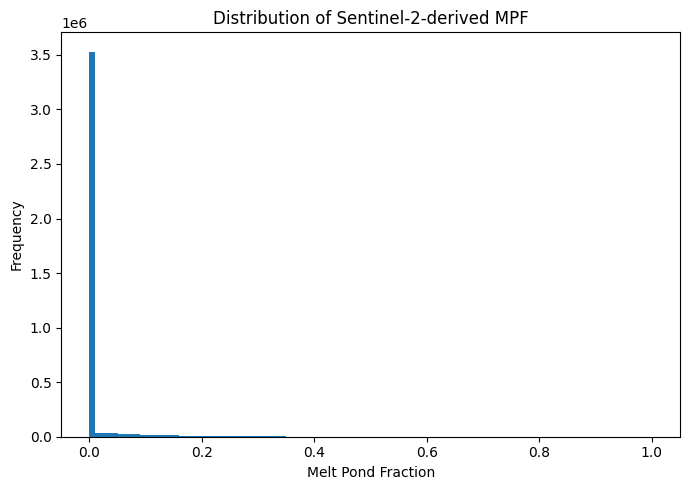

In [16]:
plt.figure(figsize=(7, 5))
plt.hist(mpf_vals, bins=100)
plt.xlabel("Melt Pond Fraction")
plt.ylabel("Frequency")
plt.title("Distribution of Sentinel-2-derived MPF")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_mpf_histogram.png", dpi=300)
plt.show()

### Interpretation

The MPF distribution is highly skewed toward zero. Most pixels have melt pond fraction values very close to 0, while only a small number of pixels have higher MPF values.

This is important for the regression stage because a model could achieve a low overall error by mainly predicting low MPF values. Therefore, later notebooks should not rely only on global metrics such as RMSE or MAE. They should also compare predicted versus observed MPF, inspect residuals, and examine whether the model can reproduce the rarer higher-MPF areas.

The strong imbalance also explains why the full 0–1 MPF colour scale makes most of the spatial variation difficult to see. A zoomed MPF colour scale, such as 0–0.02, is useful for visualising low-level spatial structure in the target variable.

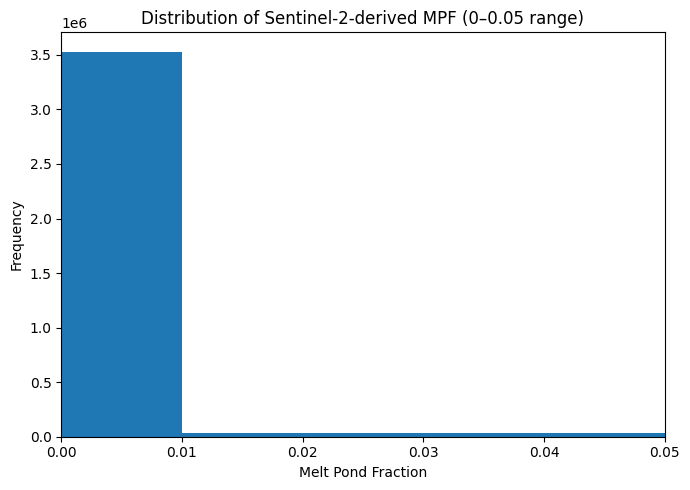

In [18]:
plt.figure(figsize=(7, 5))
plt.hist(mpf_vals, bins=100)
plt.xlabel("Melt Pond Fraction")
plt.ylabel("Frequency")
plt.title("Distribution of Sentinel-2-derived MPF (0–0.05 range)")
plt.xlim(0, 0.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_mpf_histogram_zoomed.png", dpi=300)
plt.show()

### Zoomed histogram interpretation

The zoomed histogram focuses on the 0–0.05 MPF range, where most of the data are concentrated. This makes the low-MPF structure easier to interpret than the full 0–1 histogram.

This confirms that the target variable is not evenly distributed. The regression model will mostly be trained on low-MPF examples, so model evaluation must check whether higher-MPF pixels are predicted accurately rather than only assessing the dominant near-zero class.

## Notebook 1 conclusion

The Sentinel-2, Sentinel-3 OLCI, and MPF datasets were loaded successfully. Sentinel-2 provides dense high-resolution spatial information and the MPF target, while Sentinel-3 provides coarser 21-band OLCI reflectance features for regression. The MPF target is strongly skewed toward low values, so later model evaluation should include both quantitative metrics and spatial prediction/residual maps.

The next notebook will create misaligned and aligned S2/S3 training datasets using KDTree colocation and ECC image alignment.